<a href="https://colab.research.google.com/github/Bet-Zawl/TP_project/blob/main/TP3_Data_Cleansing_TP3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP3 - Détection et Traitement des Outliers

**Difficulté:** Intermédiaire  
**Dataset:** sales_outliers.csv  
**Description:** Identification des valeurs aberrantes avec méthodes statistiques

---


## Imports des Bibliothèques


In [61]:
# Bibliothèques de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Ignorer les warnings
import warnings
warnings.filterwarnings('ignore')

# Affichage pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print(" Bibliothèques importées avec succès!")

 Bibliothèques importées avec succès!


## Import du Dataset


In [62]:
# Charger le dataset

from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/data_cleaning_project/sales_outliers.csv'
df = pd.read_csv(file_path)

#df = pd.read_csv('sales_outliers.csv')

# Afficher les informations de base
print(f"📏 Dimensions: {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f" Taille mémoire: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n" + "="*80 + "\n")

# Aperçu des données
display(df.head())
print("\n" + "="*80 + "\n")

# Informations sur les colonnes
df.info()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📏 Dimensions: 1020 lignes × 4 colonnes
 Taille mémoire: 0.12 MB




,transaction_id,amount,product,date
0,1,1458.56,B,2023-01-01
1,2,4399.43,B,2023-01-02
2,3,1298.67,C,2023-01-03
3,4,1580.76,A,2023-01-04
4,5,946.03,C,2023-01-05




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  1020 non-null   int64  
 1   amount          1020 non-null   float64
 2   product         1020 non-null   object 
 3   date            1020 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 32.0+ KB


## Visualisation des Valeurs Manquantes


<Figure size 1400x800 with 0 Axes>

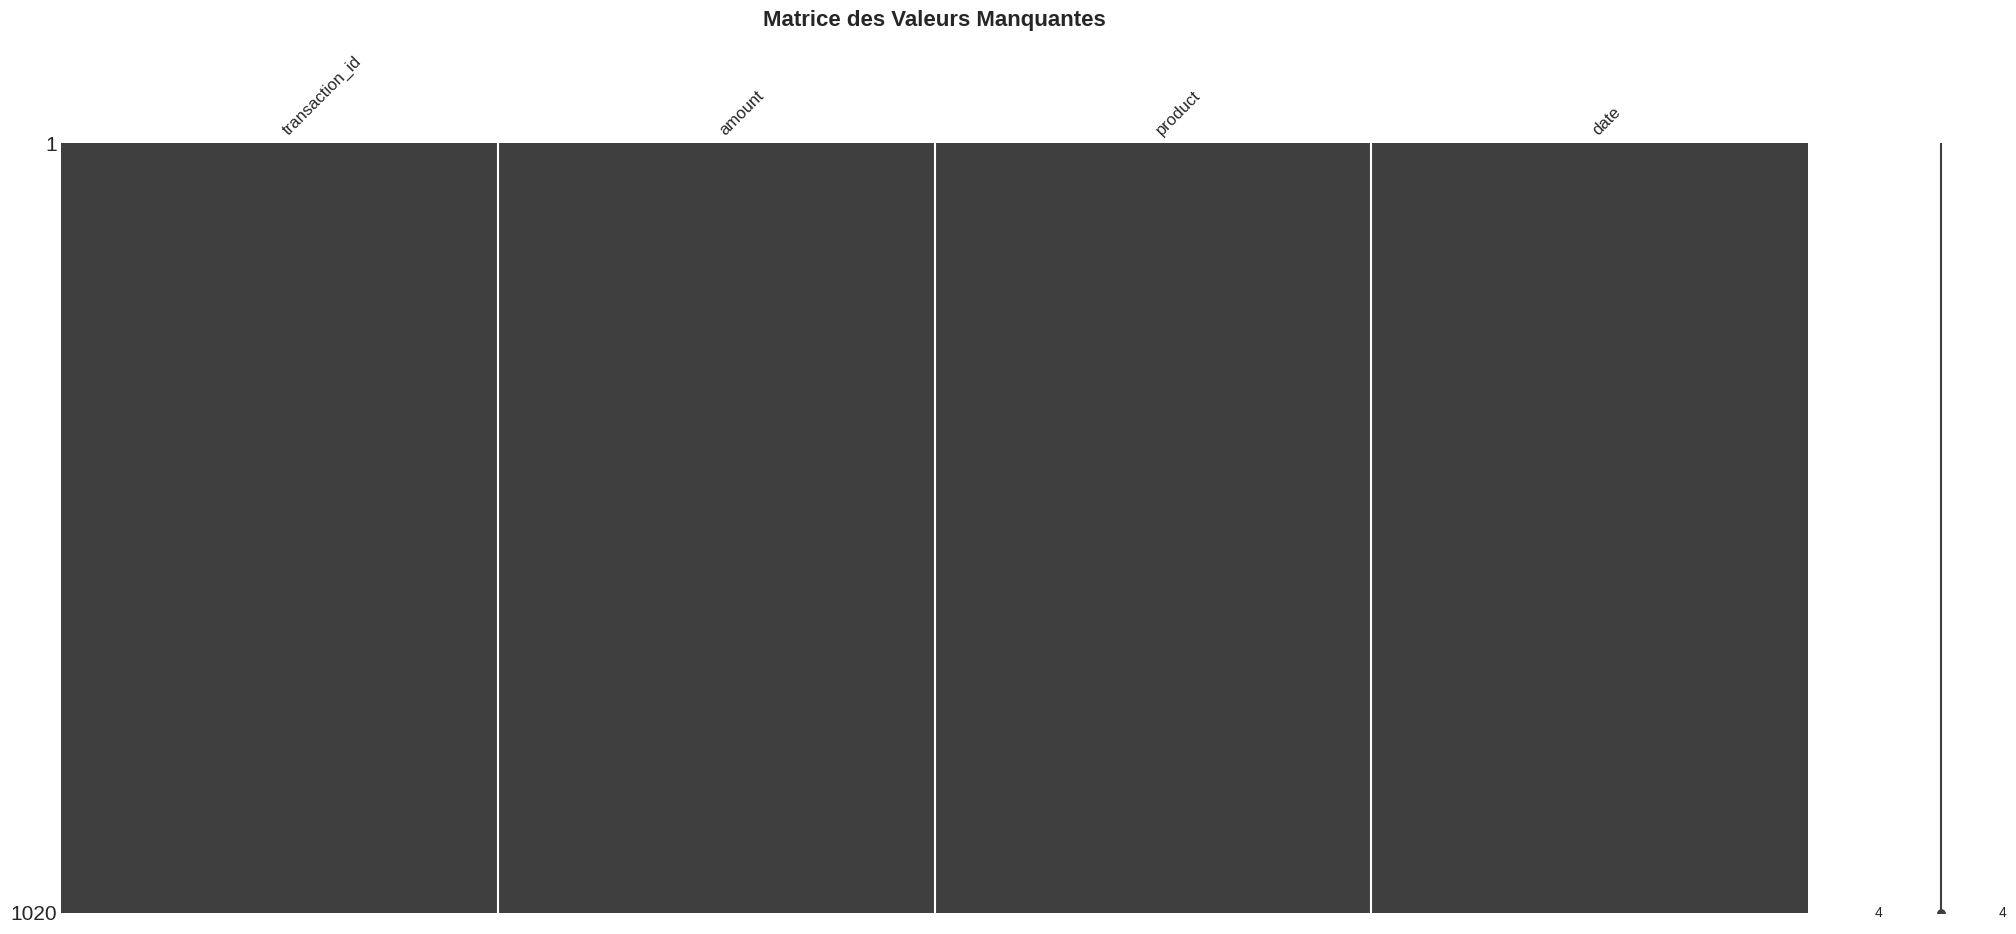


📊 Statistiques des Valeurs Manquantes:



,Nombre_Missing,Pourcentage_Missing


In [63]:
# Matrice de visualisation des valeurs manquantes
plt.figure(figsize=(14, 8))
msno.matrix(df, fontsize=12, sparkline=True)
plt.title("Matrice des Valeurs Manquantes", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Statistiques des valeurs manquantes
missing_stats = pd.DataFrame({
    'Nombre_Missing': df.isnull().sum(),
    'Pourcentage_Missing': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Pourcentage_Missing', ascending=False)

print("\n📊 Statistiques des Valeurs Manquantes:\n")
display(missing_stats[missing_stats['Nombre_Missing'] > 0])


## Questions Préalables

**Avant de commencer le TP, répondez aux questions suivantes en analysant le dataset:**

1. Quelle est la distribution de la colonne 'amount' ?
2. Y a-t-il des valeurs négatives dans les montants ?
3. Quel est le montant maximum et semble-t-il aberrant ?
4. Combien d'outliers détecte la méthode IQR pour 'amount' ?
5. Combien d'outliers détecte la méthode Z-score (threshold=3) ?
6. Les deux méthodes identifient-elles les mêmes outliers ?
7. Quelle proportion du dataset représentent les outliers ?
8. Y a-t-il une corrélation entre outliers et une catégorie spécifique ?
9. Les outliers sont-ils des erreurs ou des valeurs légitimes ?
10. Comment la moyenne change-t-elle après traitement des outliers ?


In [64]:
# Cellule pour vos réponses et analyses
# Utilisez cette cellule pour explorer les données et répondre aux questions

# Exemple d'analyses:
#df.describe()
#df['product'].value_counts()
print(df.isnull().sum())
print(df.duplicated().sum())
# etc.

print("Réponses aux questions:")
print("="*80)

# Écrivez vos réponses ici


transaction_id    0
amount            0
product           0
date              0
dtype: int64
0
Réponses aux questions:


## Étapes du TP

**Suivez les étapes ci-dessous pour nettoyer le dataset:**

### Étape 1: Visualiser la distribution avec boxplot et histogramme
### Étape 2: Calculer les statistiques descriptives
### Étape 3: Implémenter la détection par méthode IQR
### Étape 4: Implémenter la détection par Z-score
### Étape 5: Comparer les résultats des deux méthodes
### Étape 6: Décider d'une stratégie: suppression ou capping
### Étape 7: Appliquer le capping (Winsorization) aux valeurs extrêmes
### Étape 8: Visualiser la distribution avant/après traitement
### Étape 9: Calculer l'impact sur les statistiques (moyenne, écart-type)
### Étape 10: Documenter les outliers traités dans un rapport


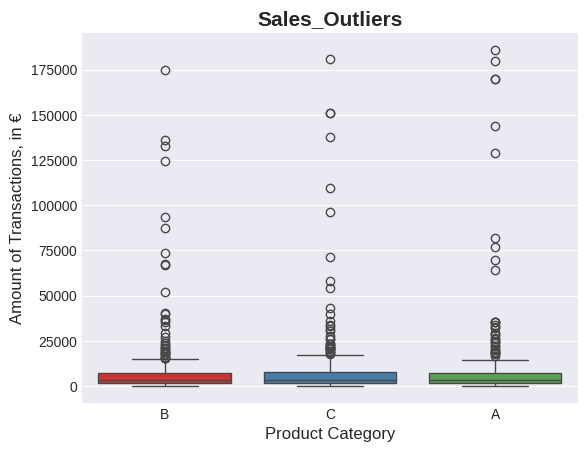

In [92]:
# ========================================
# Étape 1: Visualiser la distribution avec boxplot et histogramme
# ========================================

# TODO: Écrivez votre code ici

def box_plot(variable_x, variable_y, data, color_palette, title, title_x, title_y):
  sns.boxplot(x = variable_x, y = variable_y, data=data, palette=color_palette)
  plt.title(title, fontweight="bold", fontsize =15)
  plt.xlabel(title_x, fontsize=12)
  plt.ylabel(title_y, fontsize=12)
  plt.show()
box_plot('product', 'amount', df, "Set1", 'Sales_Outliers', 'Product Category', 'Amount of Transactions, in €')

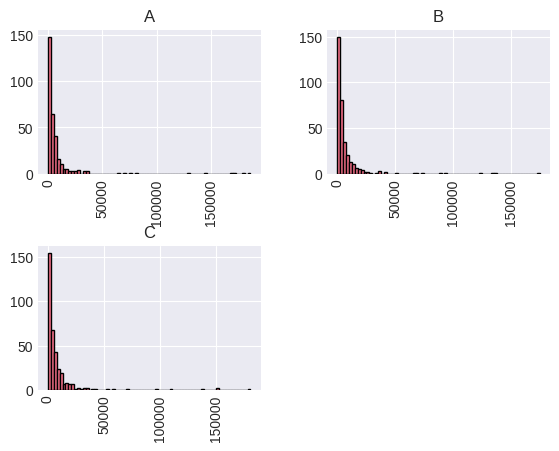

In [66]:
def histogram_plot(data, column = "variable_x", by= "variable_y"):
  data.hist(column= 'amount', by='product', bins = 70, edgecolor = 'black')
  #plt.title(title, fontweight="bold", fontsize =15)
  #plt.xlabel(title_x, fontsize=12)
  #plt.ylabel(title_y, fontsize=12)
  plt.show()
histogram_plot(df, "amount", "product")

Text(0.5, 1.0, 'Sales_Outliers')

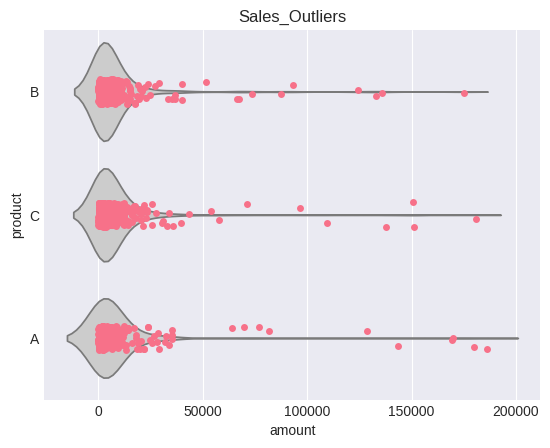

In [93]:
#Mean distribution grapgh, violin plot

ax = sns.violinplot(x =df['amount'], y =df['product'], data=df, inner=None, color=".8")

ax = sns.stripplot(x =df['amount'], y =df['product'], data=df)

ax.set_title('Sales_Outliers')

In [89]:
# ========================================
# Étape 2: Calculer les statistiques descriptives
# ========================================

# TODO: Écrivez votre code ici
display(df.describe())

# Vérification
print(f" Étape 2 complétée")

,transaction_id,amount
count,1020.00,1020.00
mean,510.50,8616.96
std,294.59,20525.04
min,1.00,79.57
25%,255.75,1441.20
50%,510.50,3152.76
75%,765.25,7221.39
max,1020.00,185913.06


 Étape 2 complétée


In [69]:
# ========================================
# Étape 3: Implémenter la détection par méthode IQR
# ========================================

# Détection par IQR
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    iqr_outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return iqr_outliers, lower_bound, upper_bound

# Utilisation
iqr_outliers, lower, upper = detect_outliers_iqr(df, 'amount')
print(f"Nombre d'outliers: {len(iqr_outliers)}")
print(f"Limites: [{lower:.2f}, {upper:.2f}]")

Nombre d'outliers: 105
Limites: [-7229.09, 15891.68]


In [70]:
# ========================================
# Étape 4: Implémenter la détection par Z-score
# ========================================

# TODO: Écrivez votre code ici
from scipy import stats
import numpy as np

# Calcul du Z-score
z_scores = np.abs(stats.zscore(df['amount']))
threshold = 3

# Détection des outliers
zscore_outliers = df[z_scores > threshold]
print(f"Outliers détectés: {len(zscore_outliers)}")

# Vérification
print(f" Étape 4 complétée")

Outliers détectés: 22
 Étape 4 complétée


In [71]:
# ========================================
# Étape 5: Comparer les résultats des deux méthodes
# ========================================

# TODO: Écrivez votre code ici
if  len(iqr_outliers)> len(zscore_outliers):
  print(f"IQR detected more outliners than Z_score method")
elif len(iqr_outliers) < len(zscore_outliers):
  print(f"IQR method detected fewer outliners than Z_score method")
else:
  print("No significant difference")

# Vérification
print(f" Étape 5 complétée")

IQR detected more outliners than Z_score method
 Étape 5 complétée


In [74]:
# @title
# ========================================
# Étape 6: Décider d'une stratégie: suppression ou capping
# ========================================

# TODO: Écrivez votre code ici
print(len(iqr_outliers))
print(len(zscore_outliers))

print(f"Meme si il y a plus de détection des outliers en IQR, IQR change le taille de dataset. Donc, le capping est pris comme stratégie car il garde le taille.")
# Vérification
print(f" Étape 6 complétée")

105
22
Meme si il y a plus de détection des outliers en IQR, IQR change le taille de dataset. Donc, le capping est pris comme stratégie car il garde le taille.
 Étape 6 complétée


In [81]:
# ========================================
# Étape 7: Appliquer le capping (Winsorization) aux valeurs extrêmes
# ========================================

# TODO: Écrivez votre code ici
p5 = df.amount.quantile(0.05)
p95 = df.amount.quantile(0.95)

df_clean = df.copy()
df_clean['amount'] = df_clean['amount'].clip(lower=p5, upper=p95)
print(df_clean.shape)
# Vérification
print(f" Étape 7 complétée")

(1020, 4)
 Étape 7 complétée


 Étape 8 complétée


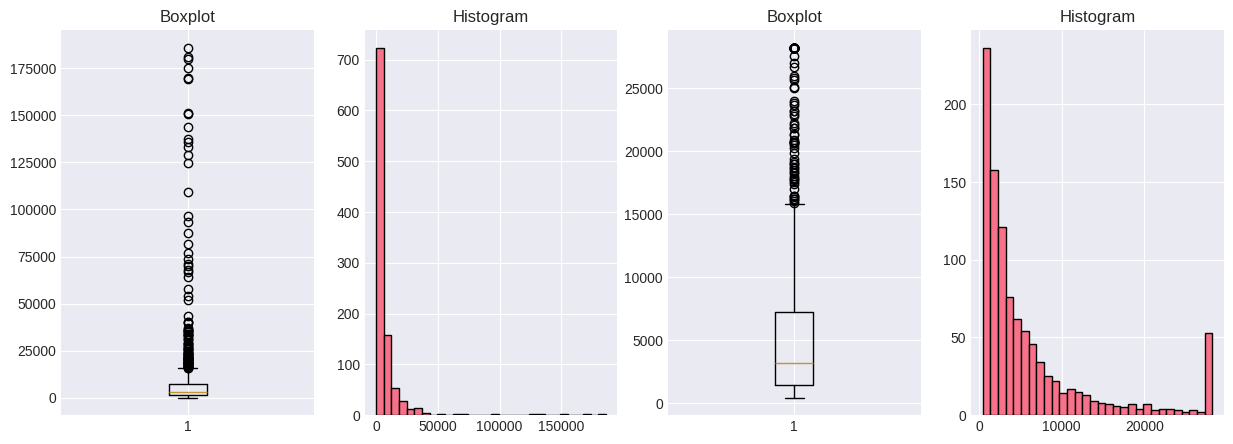

In [87]:
# ========================================
# Étape 8: Visualiser la distribution avant/après traitement
# ========================================

# TODO: Écrivez votre code ici
# Histogram 1
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

# Boxplot
axes[0].boxplot(df['amount'])
axes[0].set_title('Boxplot')

# Histogram
axes[1].hist(df['amount'], bins=30, edgecolor='black')
axes[1].set_title('Histogram')
####
axes[2].boxplot(df_clean['amount'])
axes[2].set_title('Boxplot')

# Histogram
axes[3].hist(df_clean['amount'], bins=30, edgecolor='black')
axes[3].set_title('Histogram')

# Vérification
print(f" Étape 8 complétée")

In [84]:
# ========================================
# Étape 9: Calculer l'impact sur les statistiques (moyenne, écart-type)
# ========================================

# TODO: Écrivez votre code ici
display(df.describe())
display(df_clean.describe())

# Vérification
print(f" Étape 9 complétée")

,transaction_id,amount
count,1020.00,1020.00
mean,510.50,8616.96
std,294.59,20525.04
min,1.00,79.57
25%,255.75,1441.20
50%,510.50,3152.76
75%,765.25,7221.39
max,1020.00,185913.06


,transaction_id,amount
count,1020.00,1020.00
mean,510.50,6066.40
std,294.59,7187.67
min,1.00,439.73
25%,255.75,1441.20
50%,510.50,3152.76
75%,765.25,7221.39
max,1020.00,28244.08


 Étape 9 complétée


In [91]:
# ========================================
# Étape 10: Documenter les outliers traités dans un rapport
# ========================================

# TODO: Écrivez votre code ici

outliers = [len(iqr_outliers), len(zscore_outliers)]
print(outliers)

# Vérification
print(f" Étape 10 complétée")

[105, 22]
 Étape 10 complétée


## Rapport Final

**Créez un rapport résumant toutes les transformations effectuées**


In [ ]:
# Rapport de nettoyage
rapport = {
    'Dimensions_initiales': df.shape,
    'Dimensions_finales': df.shape,  # À mettre à jour avec df_clean
    'Lignes_supprimées': 0,
    'Colonnes_supprimées': 0,
    'Valeurs_manquantes_traitées': 0,
    'Doublons_supprimés': 0,
    'Outliers_traités': 0,
    'Transformations_appliquées': []
}

print("=" * 80)
print(" " * 25 + " RAPPORT DE NETTOYAGE")
print("=" * 80)

for key, value in rapport.items():
    print(f"{key:.<40} {value}")

print("=" * 80)
print("\n✅ TP terminé avec succès!")